## DPC main

## 01. Prepare packages

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

import numpy as np
import pandas as pd
from typing import Optional, Tuple

import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import pickle
from pickle import dump
from sklearn.preprocessing import MinMaxScaler
import time
from torch.nn import ReLU

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from tqdm import tqdm
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

from sklearn.preprocessing import StandardScaler
import torch.autograd.functional as F


from tqdm import tqdm_notebook as tqdm
import warnings
warnings.filterwarnings("ignore")
import logging
logging.disable(logging.CRITICAL)

cuda is available


## 04-1. Run Simulation

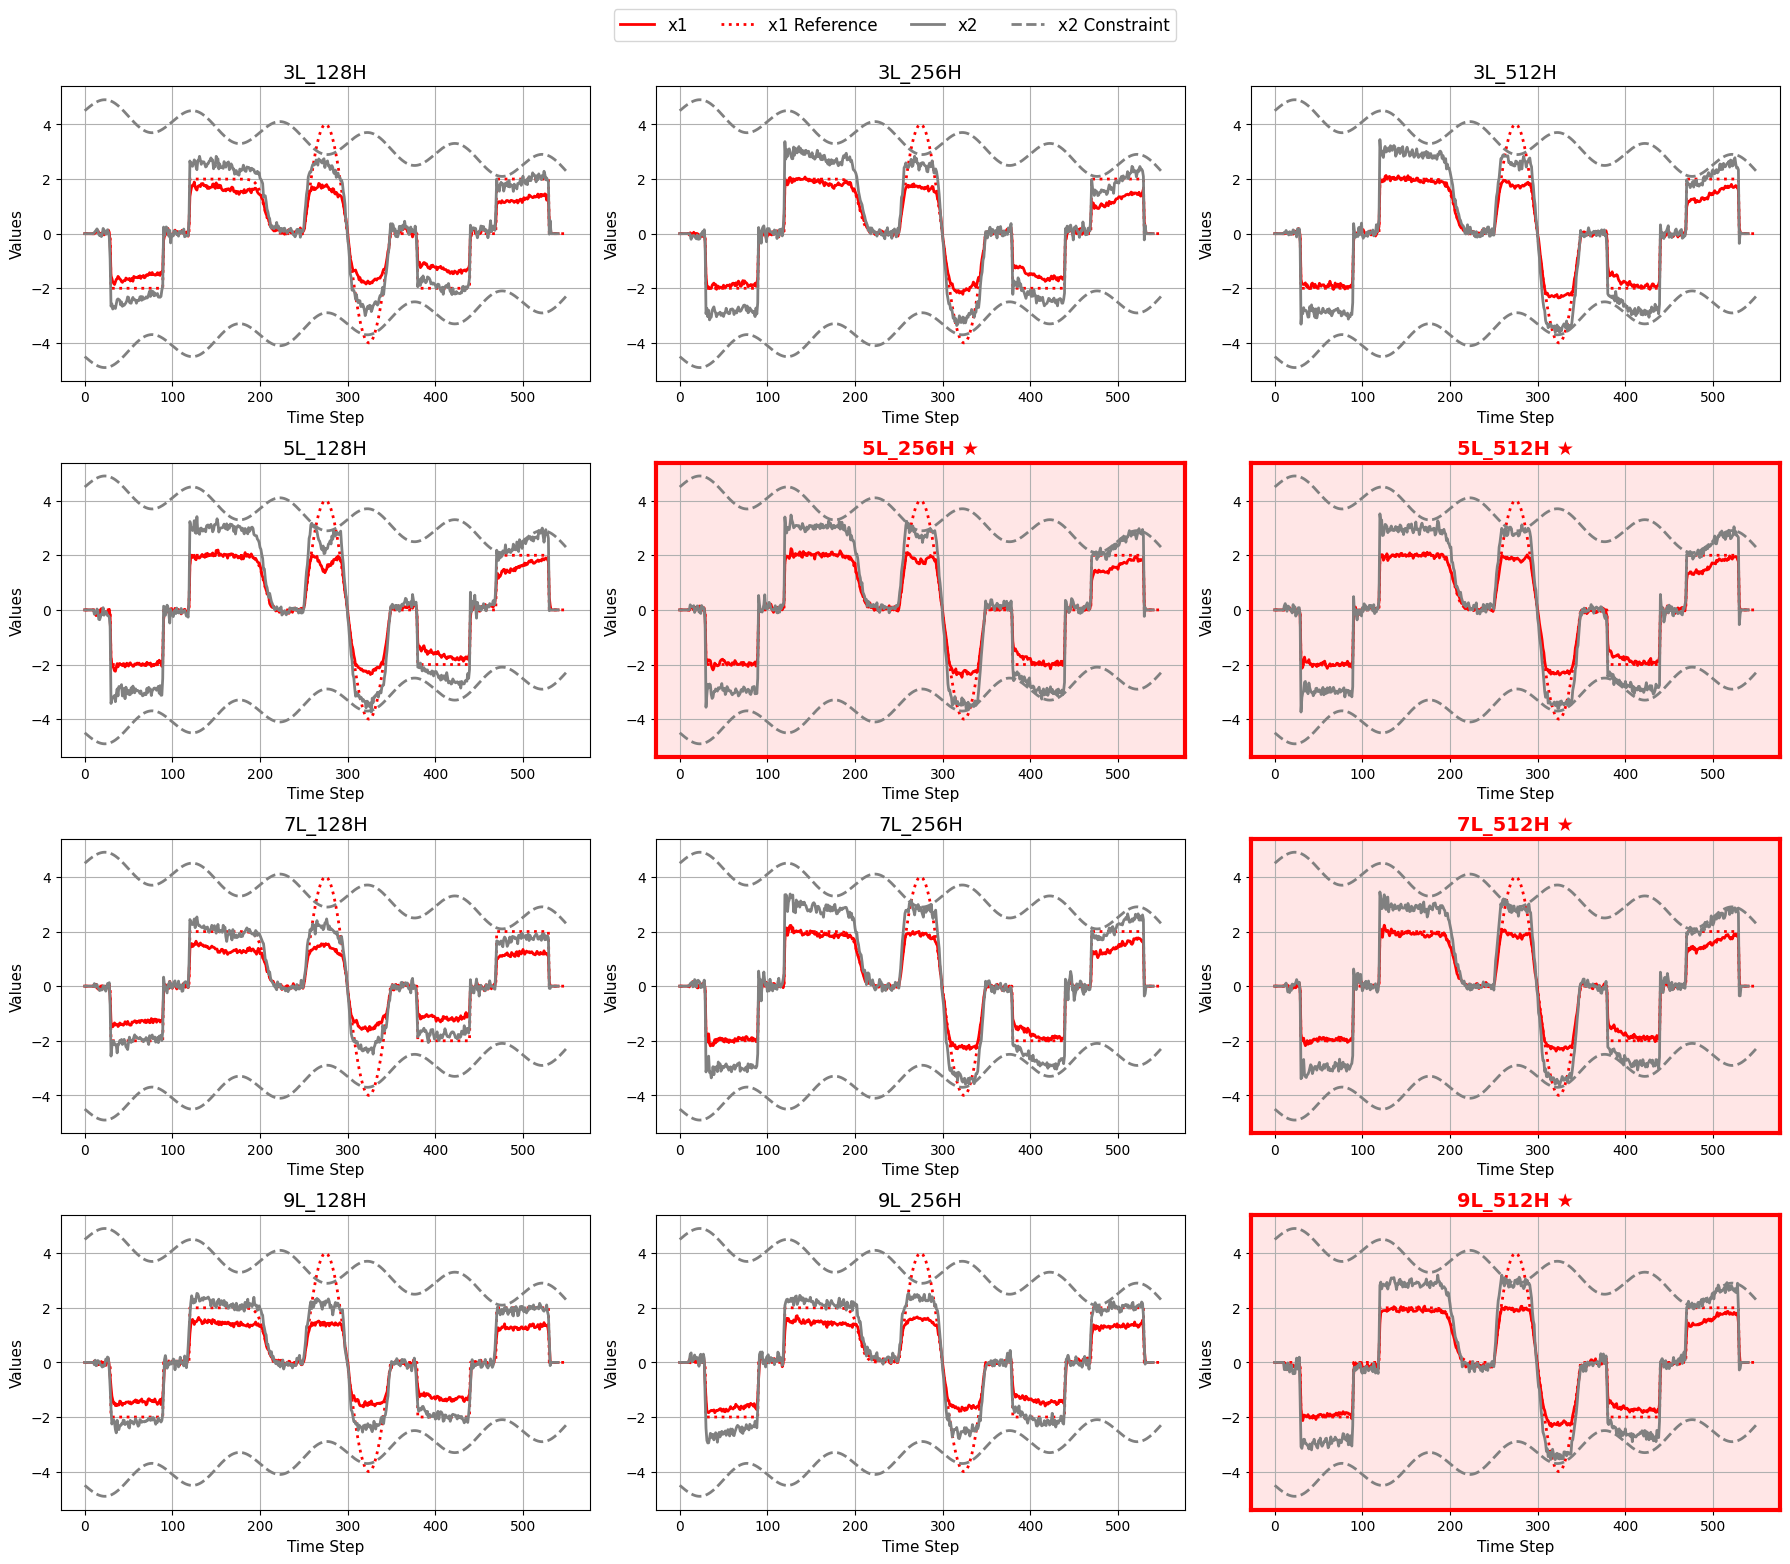

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import itertools
import re
from Policy import DPC_PolicyNN

# =====================================
# 필수: policy iteration wrapper
# =====================================
def NNPolicy_iteration(
    ref_future: torch.Tensor,
    x_past: torch.Tensor,
    u_past: torch.Tensor,
    c_fut: torch.Tensor,
    NN_Nominal,
):
    x_fut_in = ref_future.to(torch.float32)
    past_cov = torch.cat([x_past.to(torch.float32), u_past.to(torch.float32)], dim=2)
    c_fut_in = c_fut.to(torch.float32)

    u_future_policy = NN_Nominal([past_cov, x_fut_in, c_fut_in, None]).squeeze(-1)
    u_future_decision_policy = u_future_policy[:, 1, :].squeeze()

    return u_future_policy, u_future_decision_policy


# =====================================
# 모델 로드
# =====================================
window = 10
P = 10

def load_fcnn_model(setting_name, model_class, device="cpu"):
    match = re.match(r"(\d+)L_(\d+)H", setting_name)
    if match is None:
        raise ValueError(f"Invalid setting_name: {setting_name}")

    n_layers = int(match.group(1))
    hidden_dim = int(match.group(2))

    model = model_class(
        input_dim=6,
        output_dim=1,
        future_cov_dim=2,
        static_cov_dim=0,
        input_chunk_length=window,
        output_chunk_length=P,
        hidden_dim=hidden_dim,
        n_layers=n_layers
    ).to(device)

    model_path = f"/home/ftk3187/github/DPC_research/01_Toy/02_draft/policy_model_{setting_name}_case2.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model


# =====================================
# system dynamics
# =====================================
def f_ss(x0, u):
    A = np.array([[0.3, 0.1], [0.1, 0.2]])
    B = np.array([[0.5], [1.0]])
    mu = np.array([[0], [0]]) * 0
    w = np.array([[0.05], [0.1]])
    x = A @ x0 + B * u + np.random.normal(mu, w, size=(2, 1))
    return x


# =====================================
# 단일 시나리오 rollout
# =====================================
def run_single_case(model):
    with torch.no_grad():
        scaling = 2

        Ref_traj_step = torch.tensor(
            np.repeat(np.array([0, -scaling, -scaling, 0, scaling, scaling]), 30),
            dtype=torch.float32
        )

        def sigmoid(x):
            return 1 / (1 + np.exp(-x / 4))

        x = np.linspace(0, 50, 50)
        y = -sigmoid(x - 25) * scaling + scaling
        Ref_traj_sigmoid = torch.tensor(y, dtype=torch.float32)

        x_sin = np.linspace(0, 2 * np.pi, 100)
        y_sin = 2*scaling * np.sin(x_sin)
        Ref_traj_sin = torch.tensor(y_sin, dtype=torch.float32)

        Ref_traj = torch.cat((
            Ref_traj_step,
            Ref_traj_sigmoid,
            torch.zeros(20, dtype=torch.float32),
            Ref_traj_sin,
            Ref_traj_step,
            torch.zeros(20, dtype=torch.float32)
        ))
        tot_step = len(Ref_traj)

        x_constraint = np.linspace(0, tot_step, tot_step)
        C_Ref_traj_up = torch.tensor(
            4.5 + 0.5 * np.sin(2 * np.pi * x_constraint / 100) - 0.004 * x_constraint,
            dtype=torch.float32
        )
        C_Ref_traj_low = -C_Ref_traj_up

        x1_diff = 9.32425809
        x2_diff = 14.13760952
        u_diff = 9.992800291743697

        # normalize
        Ref_traj = Ref_traj / (x1_diff / 2)
        C_Ref_traj_low = C_Ref_traj_low / (x2_diff / 2)
        C_Ref_traj_up = C_Ref_traj_up / (x2_diff / 2)

        sliding_data_ref_x1 = Ref_traj.unfold(0, window, 1)
        sliding_data_con_x2_low = C_Ref_traj_low.unfold(0, window, 1)
        sliding_data_con_x2_up = C_Ref_traj_up.unfold(0, window, 1)
        sliding_data_con_x2 = torch.stack((sliding_data_con_x2_low, sliding_data_con_x2_up), dim=-1)

        num_steps = len(Ref_traj) - window + 1

        x_trajectory = torch.zeros(num_steps, 2, dtype=torch.float32)
        u_trajectory = torch.zeros(num_steps, 1, dtype=torch.float32)

        for i in range(num_steps - 20):
            x_past_policy = x_trajectory[i:i+window, :].unsqueeze(0)
            u_past_policy = u_trajectory[i:i+window, :].unsqueeze(0)

            x_ref_policy = sliding_data_ref_x1[i+window].unsqueeze(0)
            c_fut_policy = sliding_data_con_x2[i+window].unsqueeze(0)

            _, u_future_decision_policy = NNPolicy_iteration(
                x_ref_policy, x_past_policy, u_past_policy, c_fut_policy, model
            )

            u_trajectory[i+window] = u_future_decision_policy.squeeze()

            x_f = x_trajectory[i+window, :].unsqueeze(-1).clone()
            u_f = u_future_decision_policy.unsqueeze(0).unsqueeze(0).clone()

            # denormalize before dynamics
            x_f[0] *= (x1_diff / 2)
            x_f[1] *= (x2_diff / 2)
            u_f[0] *= (u_diff / 2)

            x_f_np = x_f.detach().cpu().numpy()
            u_f_np = u_f.detach().cpu().numpy()

            x_next = torch.tensor(f_ss(x_f_np, u_f_np), dtype=torch.float32).squeeze(-1)

            # renormalize
            x_next[0] /= (x1_diff / 2)
            x_next[1] /= (x2_diff / 2)

            x_trajectory[i+window+1, :] = x_next

        # denormalize for plotting
        x_trajectory[:, 0] *= (x1_diff / 2)
        x_trajectory[:, 1] *= (x2_diff / 2)
        u_trajectory[:, 0] *= (u_diff / 2)
        Ref_traj *= (x1_diff / 2)
        C_Ref_traj_low *= (x2_diff / 2)
        C_Ref_traj_up *= (x2_diff / 2)

        return x_trajectory, u_trajectory, Ref_traj, C_Ref_traj_low, C_Ref_traj_up


# =====================================
# 12개 모델 로드
# =====================================
layer_list = [3, 5, 7, 9]
hidden_dim_list = [128, 256, 512]

setting_list = [f"{L}L_{H}H" for L in layer_list for H in hidden_dim_list]

models = {}
for setting_name in setting_list:
    #print(f"Loading {setting_name}")
    models[setting_name] = load_fcnn_model(setting_name, DPC_PolicyNN, device="cpu")


# =====================================
# 12개 모델 실행
# =====================================
results_all = {}
for setting_name in setting_list:
    #print(f"Running {setting_name}")
    results_all[setting_name] = run_single_case(models[setting_name])


# =====================================
# 4x3 subplot
# =====================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

# 🔴 강조할 모델
highlight_models = ["5L_256H", "5L_512H", "7L_512H", "9L_512H"]

for idx, setting_name in enumerate(setting_list):
    ax = axes[idx]

    x_trajectory, u_trajectory, Ref_traj, C_Ref_traj_low, C_Ref_traj_up = results_all[setting_name]

    x1 = x_trajectory[:, 0].detach().cpu().numpy()
    x2 = x_trajectory[:, 1].detach().cpu().numpy()
    x1_ref = Ref_traj.detach().cpu().numpy()
    x2_low = C_Ref_traj_low.detach().cpu().numpy()
    x2_up = C_Ref_traj_up.detach().cpu().numpy()

    # =========================
    # plot
    # =========================
    l1, = ax.plot(x1, label="x1", color="r", linewidth=2)
    l2, = ax.plot(x1_ref, label="x1 Reference", color="r", linestyle="dotted", linewidth=2)
    l3, = ax.plot(x2, label="x2", color="gray", linewidth=2)
    l4, = ax.plot(x2_low, label="x2 Constraint", color="gray", linestyle="dashed", linewidth=2)
    ax.plot(x2_up, color="gray", linestyle="dashed", linewidth=2)

    # =========================
    # 기본 스타일
    # =========================
    ax.set_xlabel("Time Step", fontsize=11)
    ax.set_ylabel("Values", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.grid()

    # =========================
    # 🔥 강조 (핵심)
    # =========================
    if setting_name in highlight_models:
        # 테두리
        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

        # 제목 강조
        ax.set_title(f"{setting_name} ★", color="red", fontsize=14, fontweight="bold")

        # 배경 살짝
        ax.set_facecolor("#ffe6e6")
    else:
        ax.set_title(setting_name, fontsize=14)

# =========================
# 공통 legend
# =========================
fig.legend(
    handles=[l1, l2, l3, l4],
    labels=["x1", "x1 Reference", "x2", "x2 Constraint"],
    loc="upper center",
    ncol=4,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.98)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

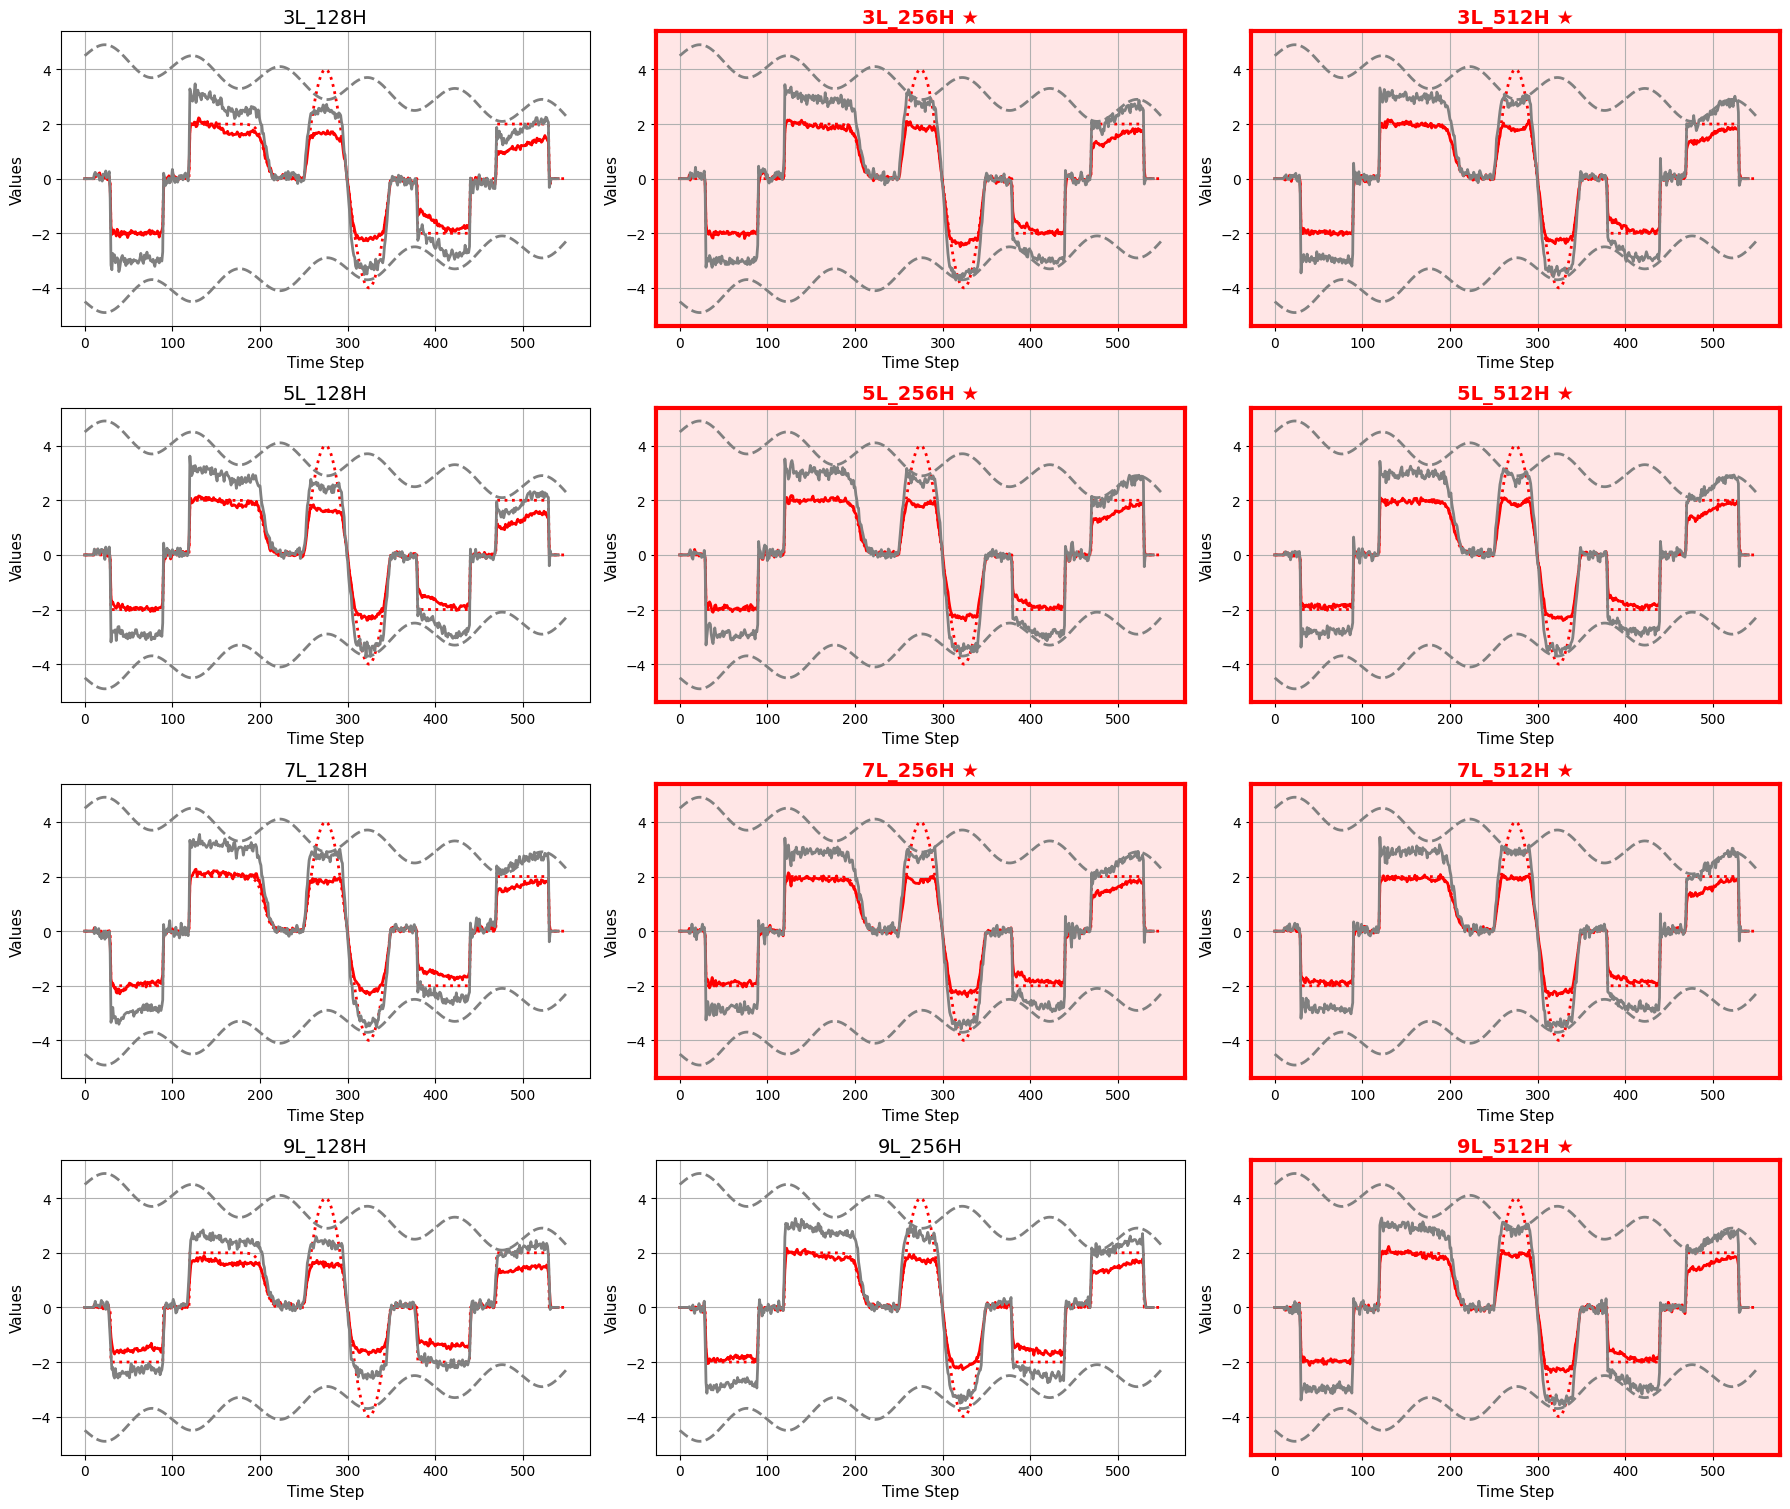

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import itertools
import re
from Policy import DPC_PolicyNN

# =====================================
# 필수: policy iteration wrapper
# =====================================
def NNPolicy_iteration(
    ref_future: torch.Tensor,
    x_past: torch.Tensor,
    u_past: torch.Tensor,
    c_fut: torch.Tensor,
    NN_Nominal,
):
    x_fut_in = ref_future.to(torch.float32)
    past_cov = torch.cat([x_past.to(torch.float32), u_past.to(torch.float32)], dim=2)
    c_fut_in = c_fut.to(torch.float32)

    u_future_policy = NN_Nominal([past_cov, x_fut_in, c_fut_in, None]).squeeze(-1)
    u_future_decision_policy = u_future_policy[:, 1, :].squeeze()

    return u_future_policy, u_future_decision_policy


# =====================================
# 모델 로드
# =====================================
window = 10
P = 10

def load_fcnn_model(setting_name, model_class, device="cpu"):
    match = re.match(r"(\d+)L_(\d+)H", setting_name)
    if match is None:
        raise ValueError(f"Invalid setting_name: {setting_name}")

    n_layers = int(match.group(1))
    hidden_dim = int(match.group(2))

    model = model_class(
        input_dim=6,
        output_dim=1,
        future_cov_dim=2,
        static_cov_dim=0,
        input_chunk_length=window,
        output_chunk_length=P,
        hidden_dim=hidden_dim,
        n_layers=n_layers
    ).to(device)

    model_path = f"/home/ftk3187/github/DPC_research/01_Toy/02_draft/policy_model_{setting_name}_case3.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model


# =====================================
# system dynamics
# =====================================
def f_ss(x0, u):
    A = np.array([[0.3, 0.1], [0.1, 0.2]])
    B = np.array([[0.5], [1.0]])
    mu = np.array([[0], [0]]) * 0
    w = np.array([[0.05], [0.1]])
    x = A @ x0 + B * u + np.random.normal(mu, w, size=(2, 1))
    return x


# =====================================
# 단일 시나리오 rollout
# =====================================
def run_single_case(model):
    with torch.no_grad():
        scaling = 2

        Ref_traj_step = torch.tensor(
            np.repeat(np.array([0, -scaling, -scaling, 0, scaling, scaling]), 30),
            dtype=torch.float32
        )

        def sigmoid(x):
            return 1 / (1 + np.exp(-x / 4))

        x = np.linspace(0, 50, 50)
        y = -sigmoid(x - 25) * scaling + scaling
        Ref_traj_sigmoid = torch.tensor(y, dtype=torch.float32)

        x_sin = np.linspace(0, 2 * np.pi, 100)
        y_sin = 2*scaling * np.sin(x_sin)
        Ref_traj_sin = torch.tensor(y_sin, dtype=torch.float32)

        Ref_traj = torch.cat((
            Ref_traj_step,
            Ref_traj_sigmoid,
            torch.zeros(20, dtype=torch.float32),
            Ref_traj_sin,
            Ref_traj_step,
            torch.zeros(20, dtype=torch.float32)
        ))
        tot_step = len(Ref_traj)

        x_constraint = np.linspace(0, tot_step, tot_step)
        C_Ref_traj_up = torch.tensor(
            4.5 + 0.5 * np.sin(2 * np.pi * x_constraint / 100) - 0.004 * x_constraint,
            dtype=torch.float32
        )
        C_Ref_traj_low = -C_Ref_traj_up

        x1_diff = 9.32425809
        x2_diff = 14.13760952
        u_diff = 9.992800291743697

        # normalize
        Ref_traj = Ref_traj / (x1_diff / 2)
        C_Ref_traj_low = C_Ref_traj_low / (x2_diff / 2)
        C_Ref_traj_up = C_Ref_traj_up / (x2_diff / 2)

        sliding_data_ref_x1 = Ref_traj.unfold(0, window, 1)
        sliding_data_con_x2_low = C_Ref_traj_low.unfold(0, window, 1)
        sliding_data_con_x2_up = C_Ref_traj_up.unfold(0, window, 1)
        sliding_data_con_x2 = torch.stack((sliding_data_con_x2_low, sliding_data_con_x2_up), dim=-1)

        num_steps = len(Ref_traj) - window + 1

        x_trajectory = torch.zeros(num_steps, 2, dtype=torch.float32)
        u_trajectory = torch.zeros(num_steps, 1, dtype=torch.float32)

        for i in range(num_steps - 20):
            x_past_policy = x_trajectory[i:i+window, :].unsqueeze(0)
            u_past_policy = u_trajectory[i:i+window, :].unsqueeze(0)

            x_ref_policy = sliding_data_ref_x1[i+window].unsqueeze(0)
            c_fut_policy = sliding_data_con_x2[i+window].unsqueeze(0)

            _, u_future_decision_policy = NNPolicy_iteration(
                x_ref_policy, x_past_policy, u_past_policy, c_fut_policy, model
            )

            u_trajectory[i+window] = u_future_decision_policy.squeeze()

            x_f = x_trajectory[i+window, :].unsqueeze(-1).clone()
            u_f = u_future_decision_policy.unsqueeze(0).unsqueeze(0).clone()

            # denormalize before dynamics
            x_f[0] *= (x1_diff / 2)
            x_f[1] *= (x2_diff / 2)
            u_f[0] *= (u_diff / 2)

            x_f_np = x_f.detach().cpu().numpy()
            u_f_np = u_f.detach().cpu().numpy()

            x_next = torch.tensor(f_ss(x_f_np, u_f_np), dtype=torch.float32).squeeze(-1)

            # renormalize
            x_next[0] /= (x1_diff / 2)
            x_next[1] /= (x2_diff / 2)

            x_trajectory[i+window+1, :] = x_next

        # denormalize for plotting
        x_trajectory[:, 0] *= (x1_diff / 2)
        x_trajectory[:, 1] *= (x2_diff / 2)
        u_trajectory[:, 0] *= (u_diff / 2)
        Ref_traj *= (x1_diff / 2)
        C_Ref_traj_low *= (x2_diff / 2)
        C_Ref_traj_up *= (x2_diff / 2)

        return x_trajectory, u_trajectory, Ref_traj, C_Ref_traj_low, C_Ref_traj_up


# =====================================
# 12개 모델 로드
# =====================================
layer_list = [3, 5, 7, 9]
hidden_dim_list = [128, 256, 512]

setting_list = [f"{L}L_{H}H" for L in layer_list for H in hidden_dim_list]

models = {}
for setting_name in setting_list:
    #print(f"Loading {setting_name}")
    models[setting_name] = load_fcnn_model(setting_name, DPC_PolicyNN, device="cpu")


# =====================================
# 12개 모델 실행
# =====================================
results_all = {}
for setting_name in setting_list:
    #print(f"Running {setting_name}")
    results_all[setting_name] = run_single_case(models[setting_name])


# =====================================
# 4x3 subplot
# =====================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

# 🔴 강조할 모델
highlight_models = ["3L_256H", "3L_512H", "5L_256H", "5L_512H", "7L_256H", "7L_512H", "9L_512H"]

for idx, setting_name in enumerate(setting_list):
    ax = axes[idx]

    x_trajectory, u_trajectory, Ref_traj, C_Ref_traj_low, C_Ref_traj_up = results_all[setting_name]

    x1 = x_trajectory[:, 0].detach().cpu().numpy()
    x2 = x_trajectory[:, 1].detach().cpu().numpy()
    x1_ref = Ref_traj.detach().cpu().numpy()
    x2_low = C_Ref_traj_low.detach().cpu().numpy()
    x2_up = C_Ref_traj_up.detach().cpu().numpy()

    # =========================
    # plot
    # =========================
    l1, = ax.plot(x1, label="x1", color="r", linewidth=2)
    l2, = ax.plot(x1_ref, label="x1 Reference", color="r", linestyle="dotted", linewidth=2)
    l3, = ax.plot(x2, label="x2", color="gray", linewidth=2)
    l4, = ax.plot(x2_low, label="x2 Constraint", color="gray", linestyle="dashed", linewidth=2)
    ax.plot(x2_up, color="gray", linestyle="dashed", linewidth=2)

    # =========================
    # 기본 스타일
    # =========================
    ax.set_xlabel("Time Step", fontsize=11)
    ax.set_ylabel("Values", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.grid()

    # =========================
    # 🔥 강조 (핵심)
    # =========================
    if setting_name in highlight_models:
        # 테두리
        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

        # 제목 강조
        ax.set_title(f"{setting_name} ★", color="red", fontsize=14, fontweight="bold")

        # 배경 살짝
        ax.set_facecolor("#ffe6e6")
    else:
        ax.set_title(setting_name, fontsize=14)

# =========================
# 공통 legend
# =========================
# fig.legend(
#     handles=[l1, l2, l3, l4],
#     labels=["x1", "x1 Reference", "x2", "x2 Constraint"],
#     loc="upper center",
#     ncol=4,
#     fontsize=12,
#     bbox_to_anchor=(0.5, 0.98)
# )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

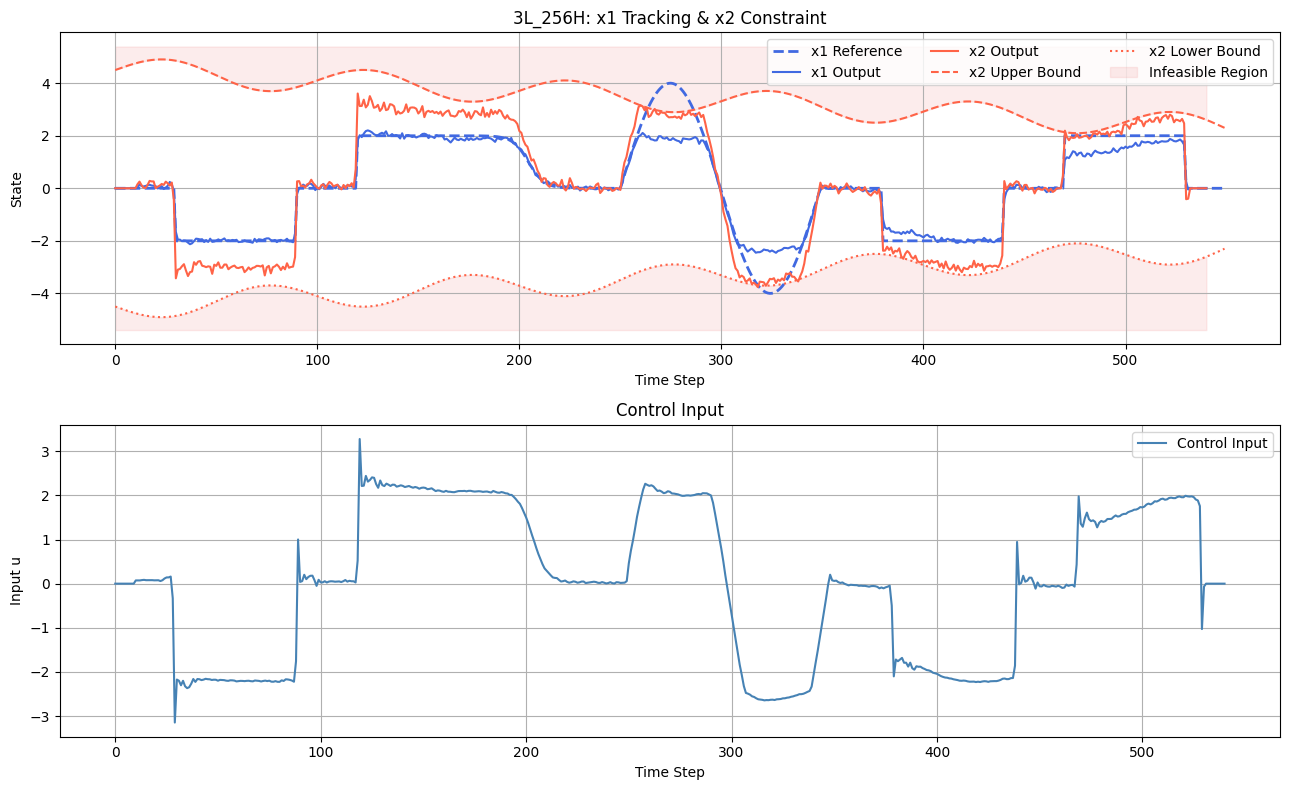

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import re
from Policy import DPC_PolicyNN

# =========================
# 설정
# =========================
setting_name = "3L_256H"
window = 10
P = 10

# =========================
# 모델 로드
# =========================
def load_fcnn_model(setting_name, model_class, device="cpu"):
    match = re.match(r"(\d+)L_(\d+)H", setting_name)
    n_layers = int(match.group(1))
    hidden_dim = int(match.group(2))

    model = model_class(
        input_dim=6,
        output_dim=1,
        future_cov_dim=2,
        static_cov_dim=0,
        input_chunk_length=window,
        output_chunk_length=P,
        hidden_dim=hidden_dim,
        n_layers=n_layers
    ).to(device)

    model_path = f"/home/ftk3187/github/DPC_research/01_Toy/02_draft/policy_model_{setting_name}_case3.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model

model = load_fcnn_model(setting_name, DPC_PolicyNN)

# =========================
# rollout 실행 (기존 함수 그대로 사용)
# =========================
x_trajectory, u_trajectory, Ref_traj, C_Ref_traj_low, C_Ref_traj_up = run_single_case(model)

# =========================
# numpy 변환
# =========================
x1 = x_trajectory[:, 0].detach().cpu().numpy()
x2 = x_trajectory[:, 1].detach().cpu().numpy()
x1_ref = Ref_traj.detach().cpu().numpy()
x2_low = C_Ref_traj_low.detach().cpu().numpy()
x2_up = C_Ref_traj_up.detach().cpu().numpy()

n_steps = len(x1)
t = np.arange(n_steps)

# =========================
# plot
# =========================
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# -------- 상단 --------
ax1 = axes[0]

ax1.plot(x1_ref, color='royalblue', linewidth=2, linestyle='--', label='x1 Reference')
ax1.plot(x1, color='royalblue', linewidth=1.5, label='x1 Output')
ax1.plot(x2, color='tomato', linewidth=1.5, label='x2 Output')
ax1.plot(x2_up, color='tomato', linestyle='--', linewidth=1.5, label='x2 Upper Bound')
ax1.plot(x2_low, color='tomato', linestyle=':', linewidth=1.5, label='x2 Lower Bound')

y_min, y_max = ax1.get_ylim()

# numpy 변환
x1 = x_trajectory[:, 0].detach().cpu().numpy()
x2 = x_trajectory[:, 1].detach().cpu().numpy()
x1_ref = Ref_traj.detach().cpu().numpy()
x2_low = C_Ref_traj_low.detach().cpu().numpy()
x2_up = C_Ref_traj_up.detach().cpu().numpy()

# 🔥 무조건 최소 길이로 통일
min_len = min(len(x1), len(x2), len(x1_ref), len(x2_low), len(x2_up))

x1 = x1[:min_len]
x2 = x2[:min_len]
x1_ref = x1_ref[:min_len]
x2_low = x2_low[:min_len]
x2_up = x2_up[:min_len]

t = np.arange(min_len)

# 🔥 constraint 바깥 영역 fill
y_min, y_max = ax1.get_ylim()

ax1.fill_between(t, x2_up, y_max, color='lightcoral', alpha=0.15, label='Infeasible Region')
ax1.fill_between(t, y_min, x2_low, color='lightcoral', alpha=0.15)

ax1.set_xlabel('Time Step')
ax1.set_ylabel('State')
ax1.set_title(f'{setting_name}: x1 Tracking & x2 Constraint')
ax1.grid(True)
ax1.legend(ncol=3)

# -------- 하단 --------
ax2 = axes[1]

u = u_trajectory[:, 0].detach().cpu().numpy()

ax2.plot(u, color='steelblue', linewidth=1.5, label='Control Input')

ax2.set_xlabel('Time Step')
ax2.set_ylabel('Input u')
ax2.set_title('Control Input')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

## 04-2. Run Simulation

Loading 3L_512H
Loading 3L_256H
Loading 3L_128H
Loading 5L_512H
Loading 5L_256H
Loading 5L_128H
Loading 7L_512H
Loading 7L_256H
Loading 7L_128H
Loading 9L_512H
Loading 9L_256H
Loading 9L_128H

Running model: 3L_512H


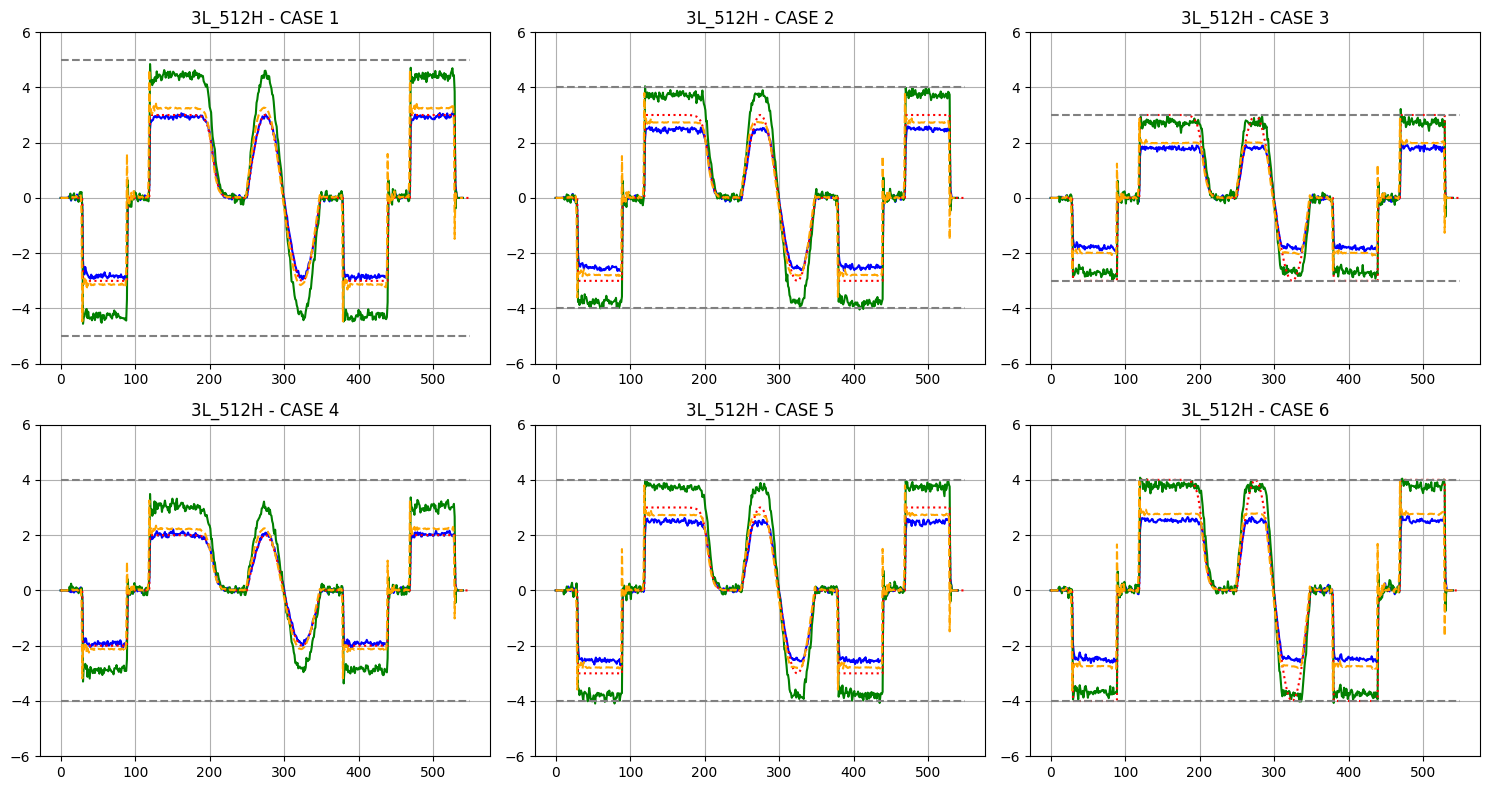


Running model: 3L_256H


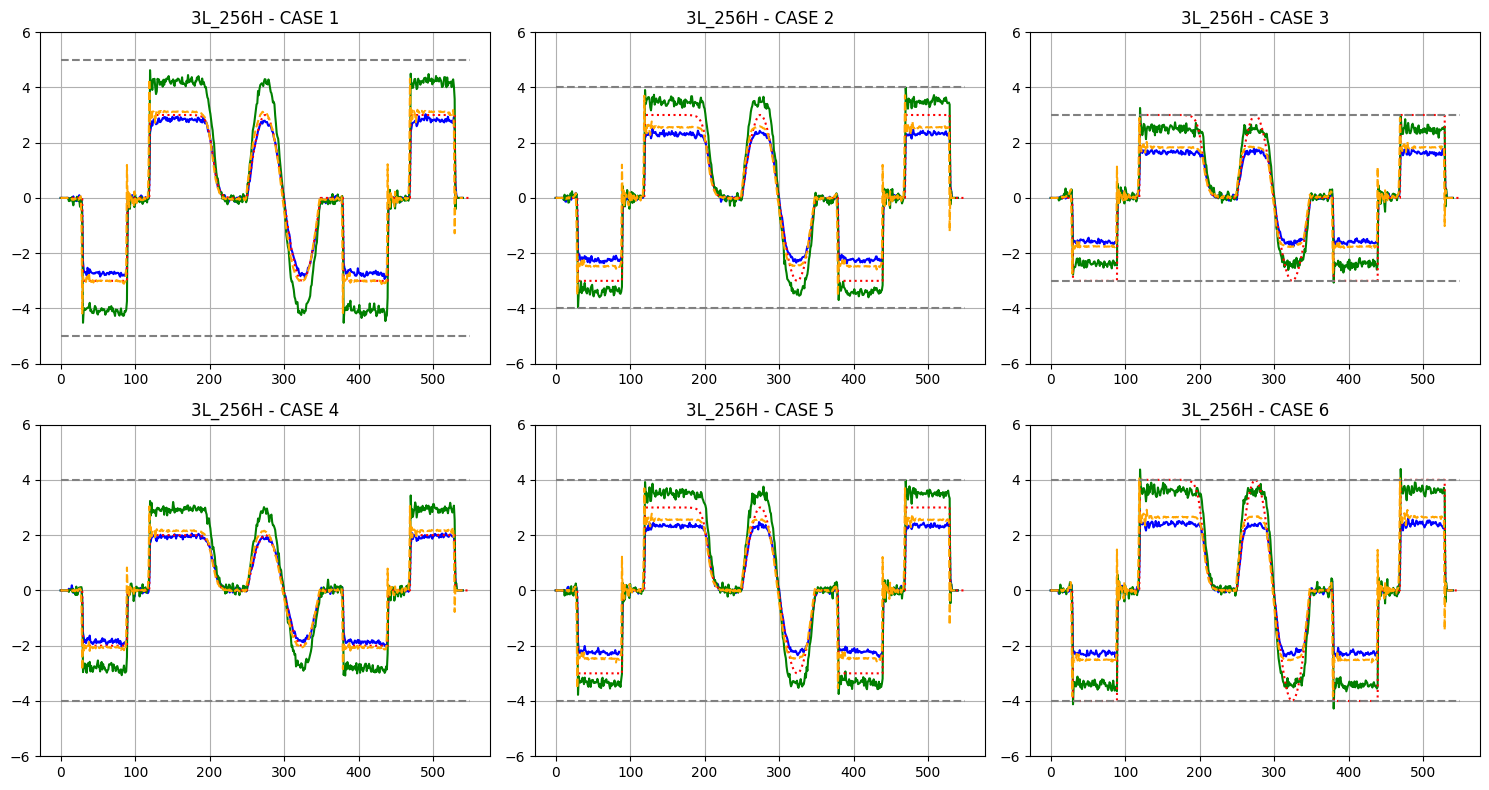


Running model: 3L_128H


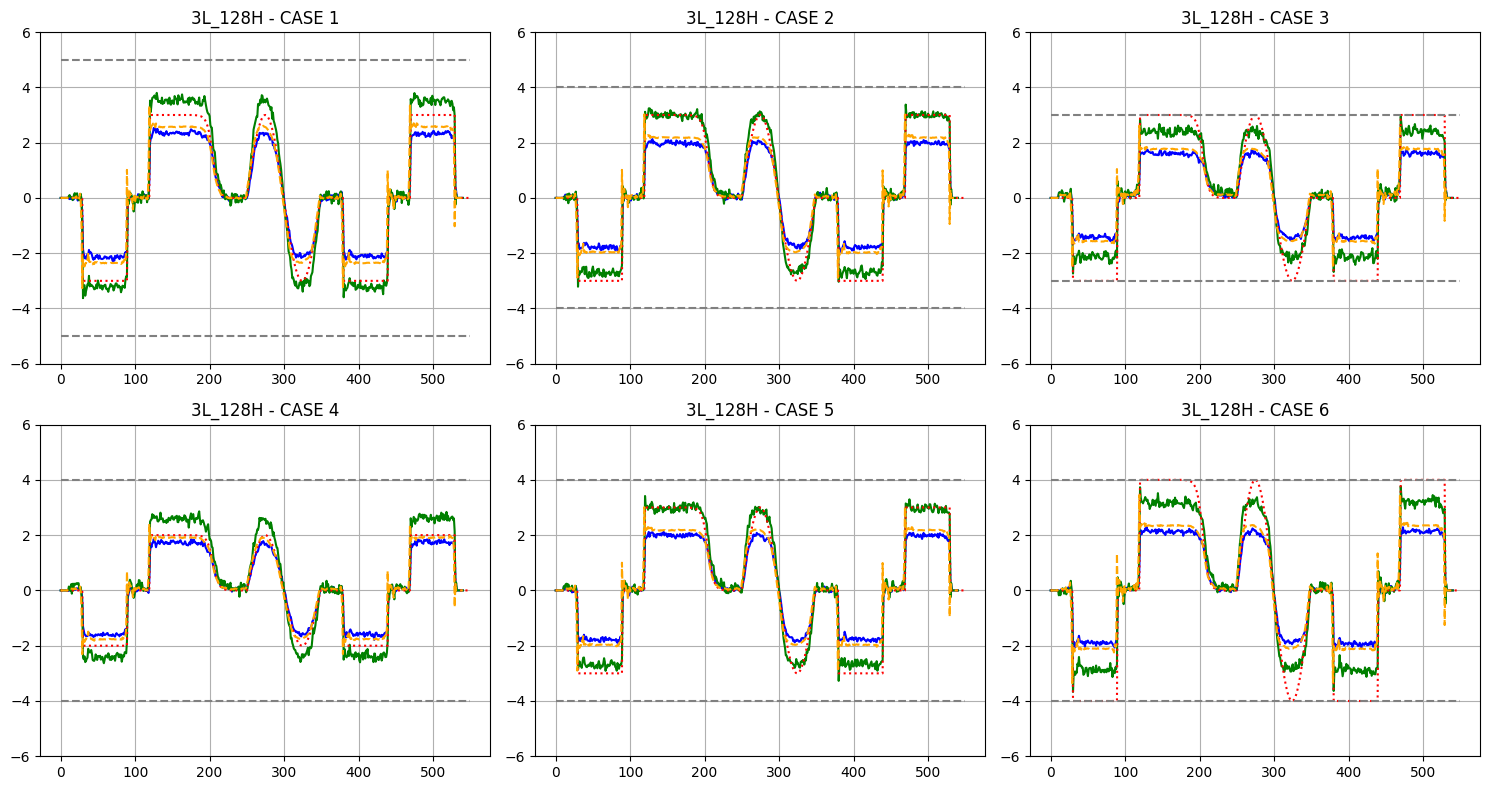


Running model: 5L_512H


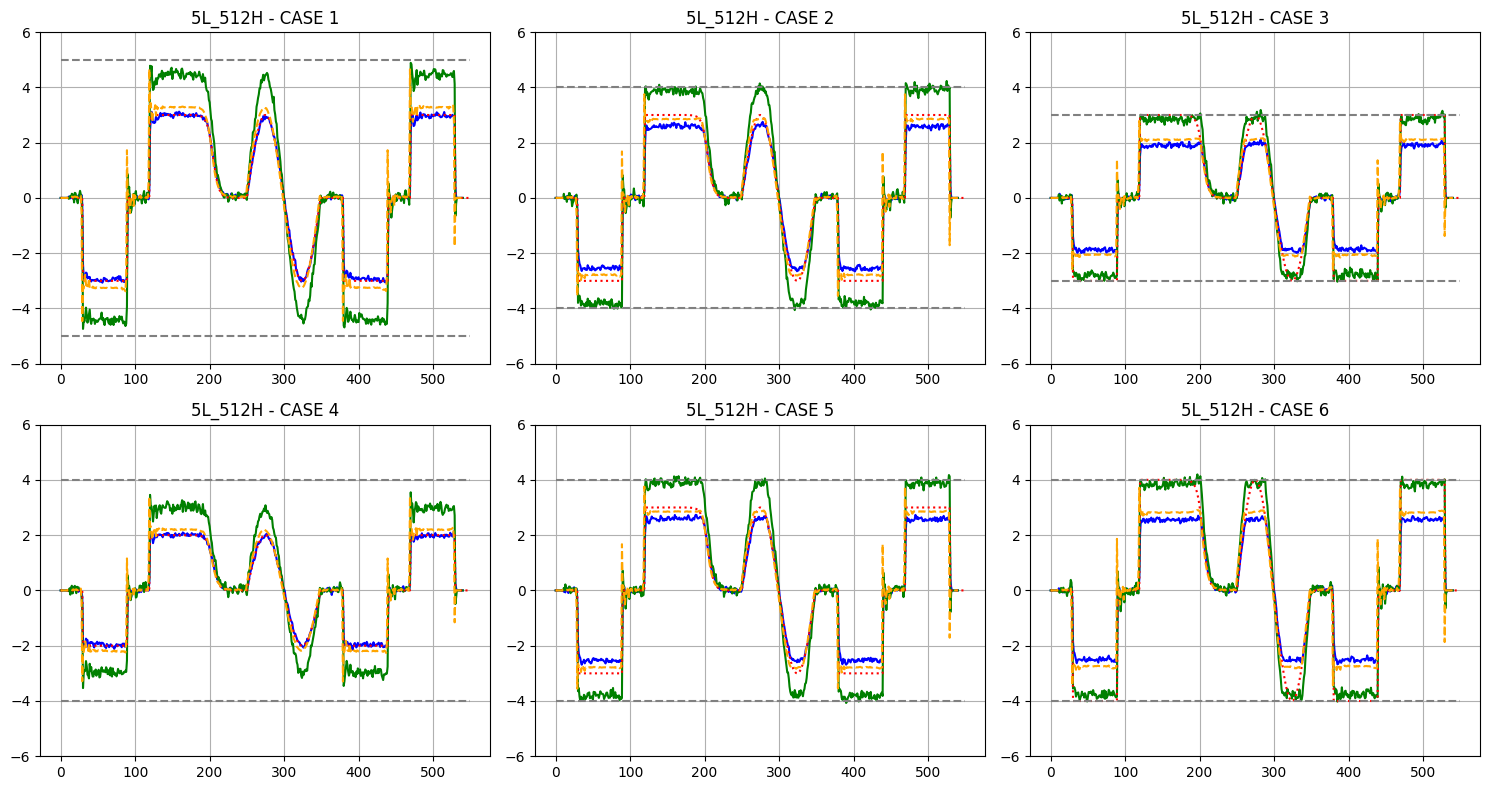


Running model: 5L_256H


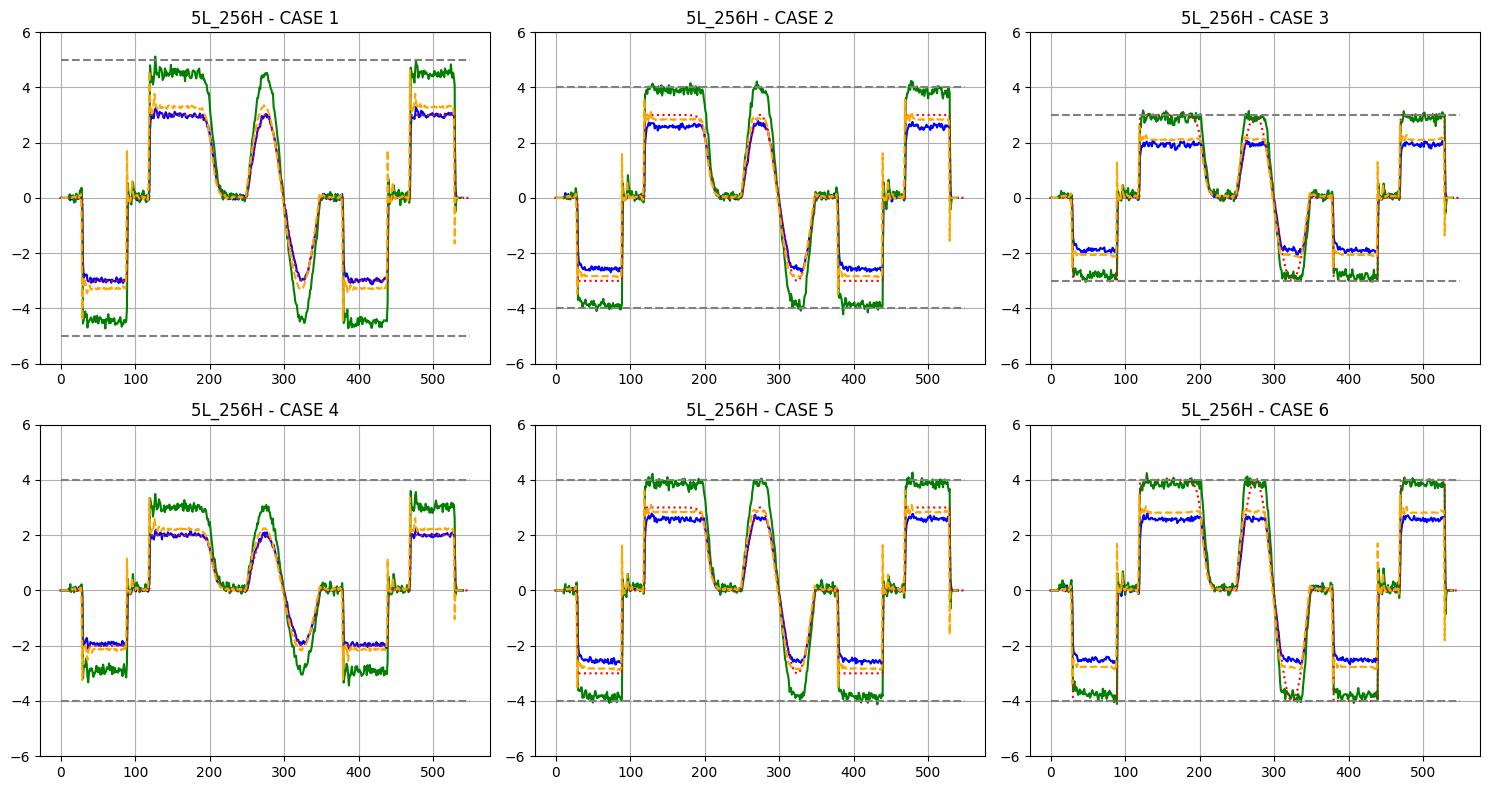


Running model: 5L_128H


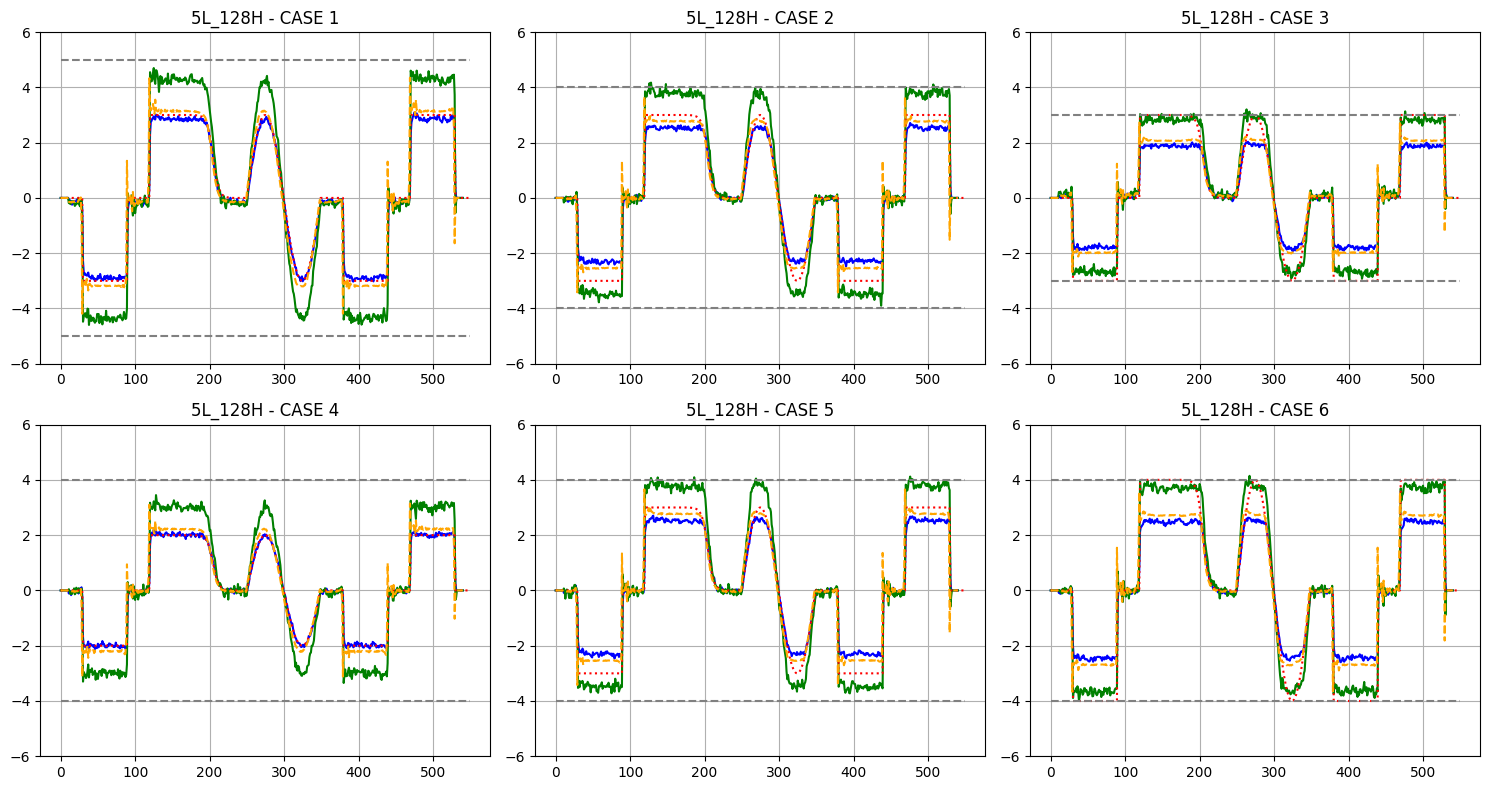


Running model: 7L_512H


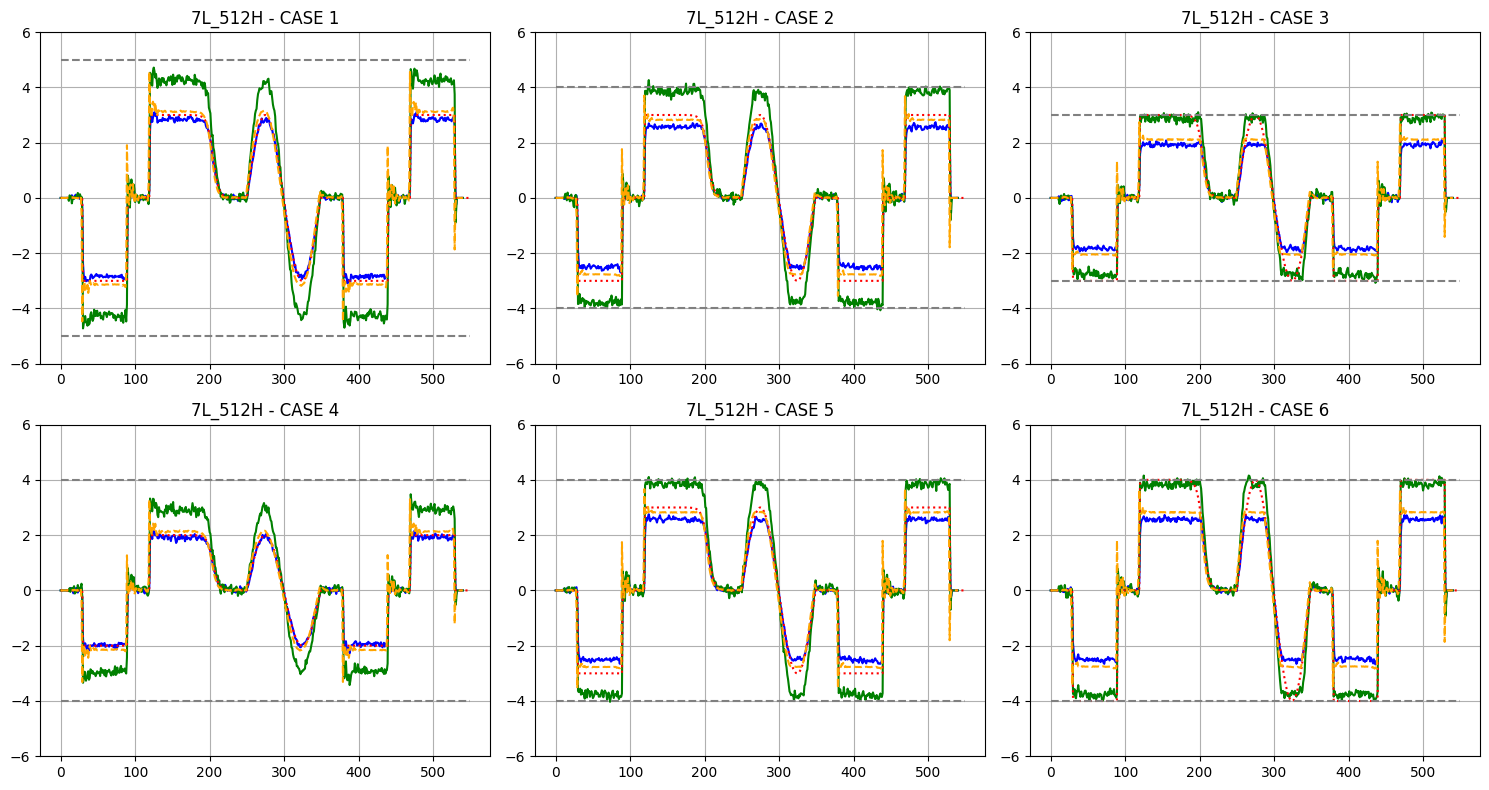


Running model: 7L_256H


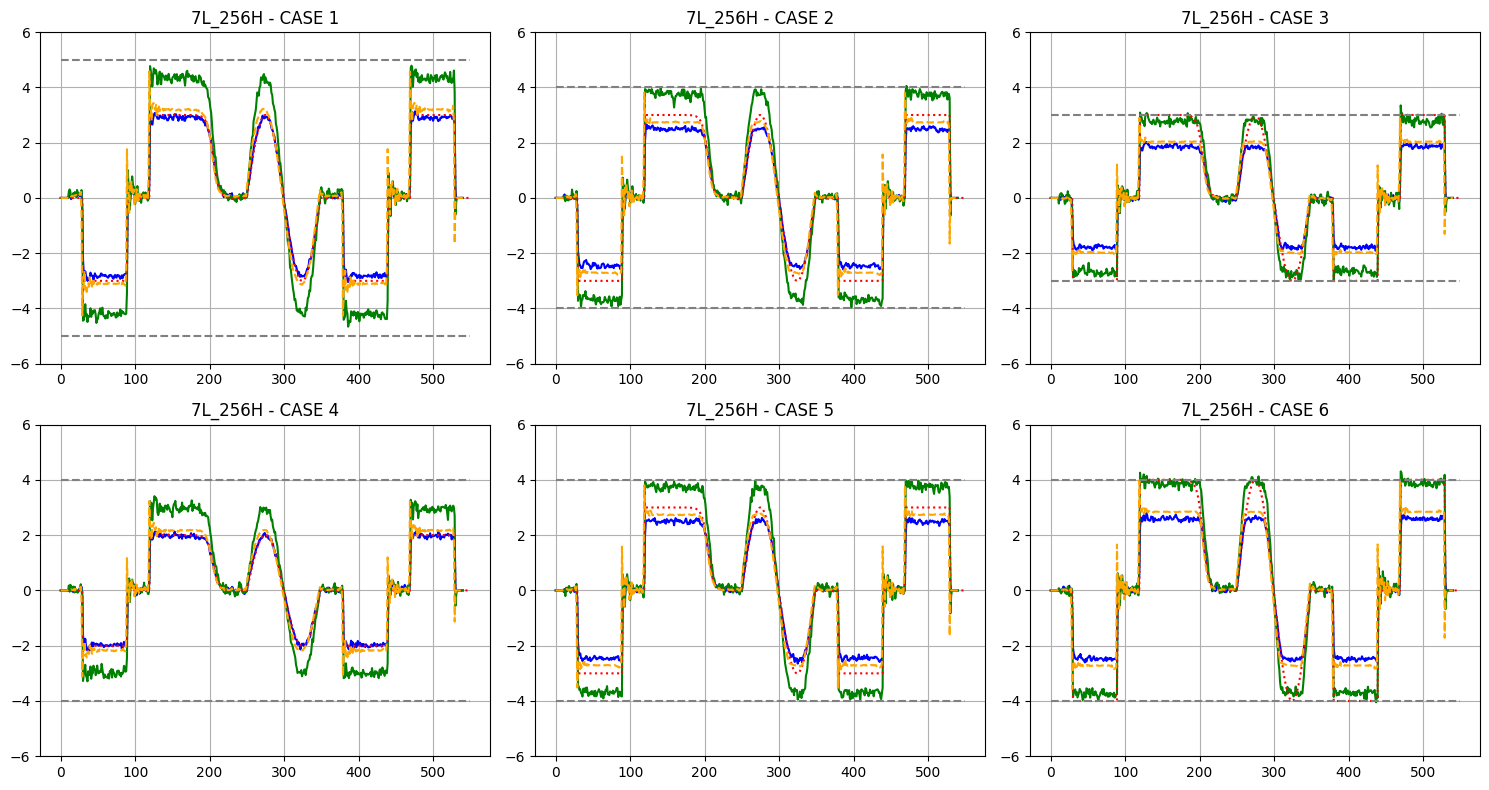


Running model: 7L_128H


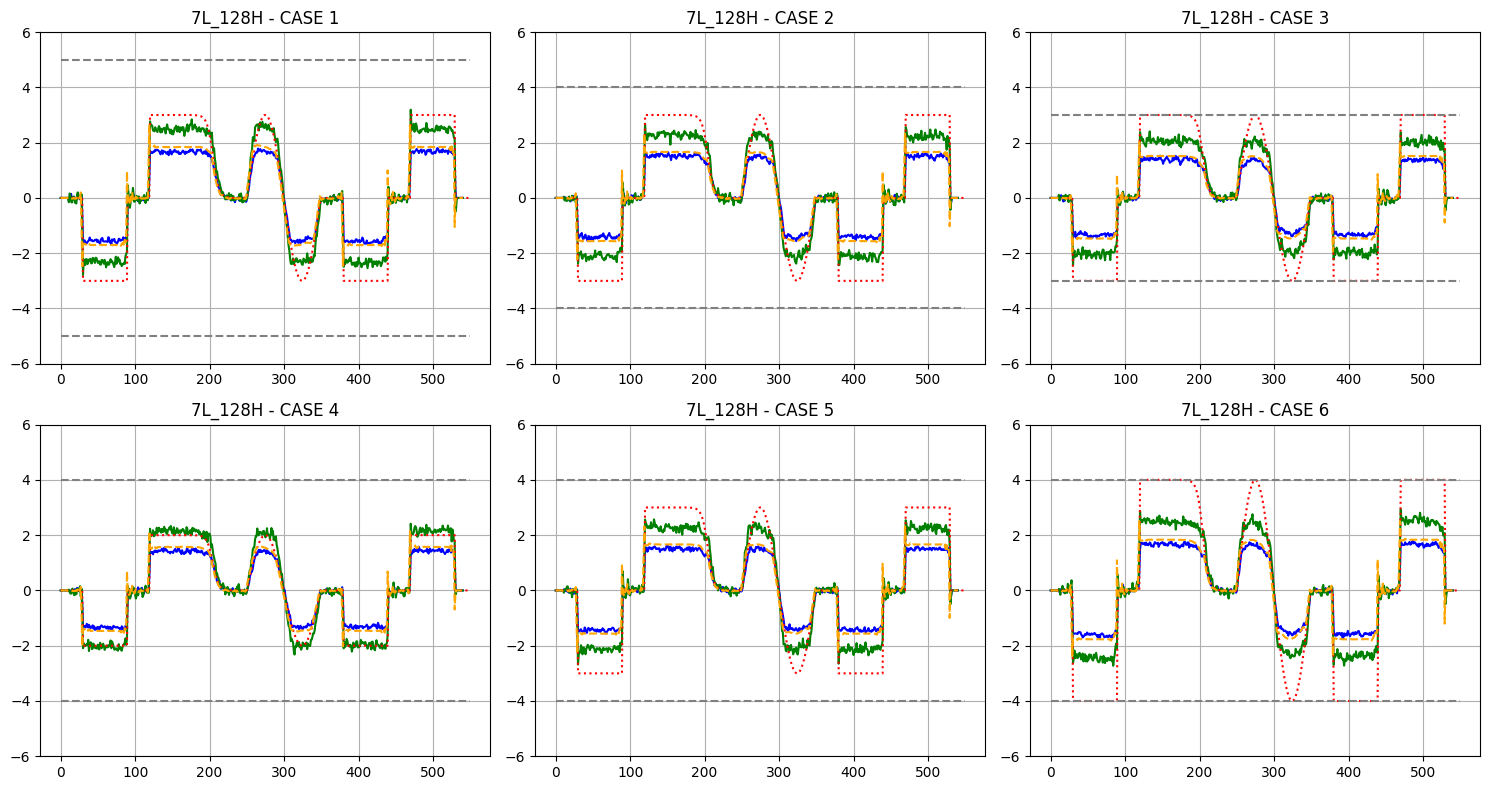


Running model: 9L_512H


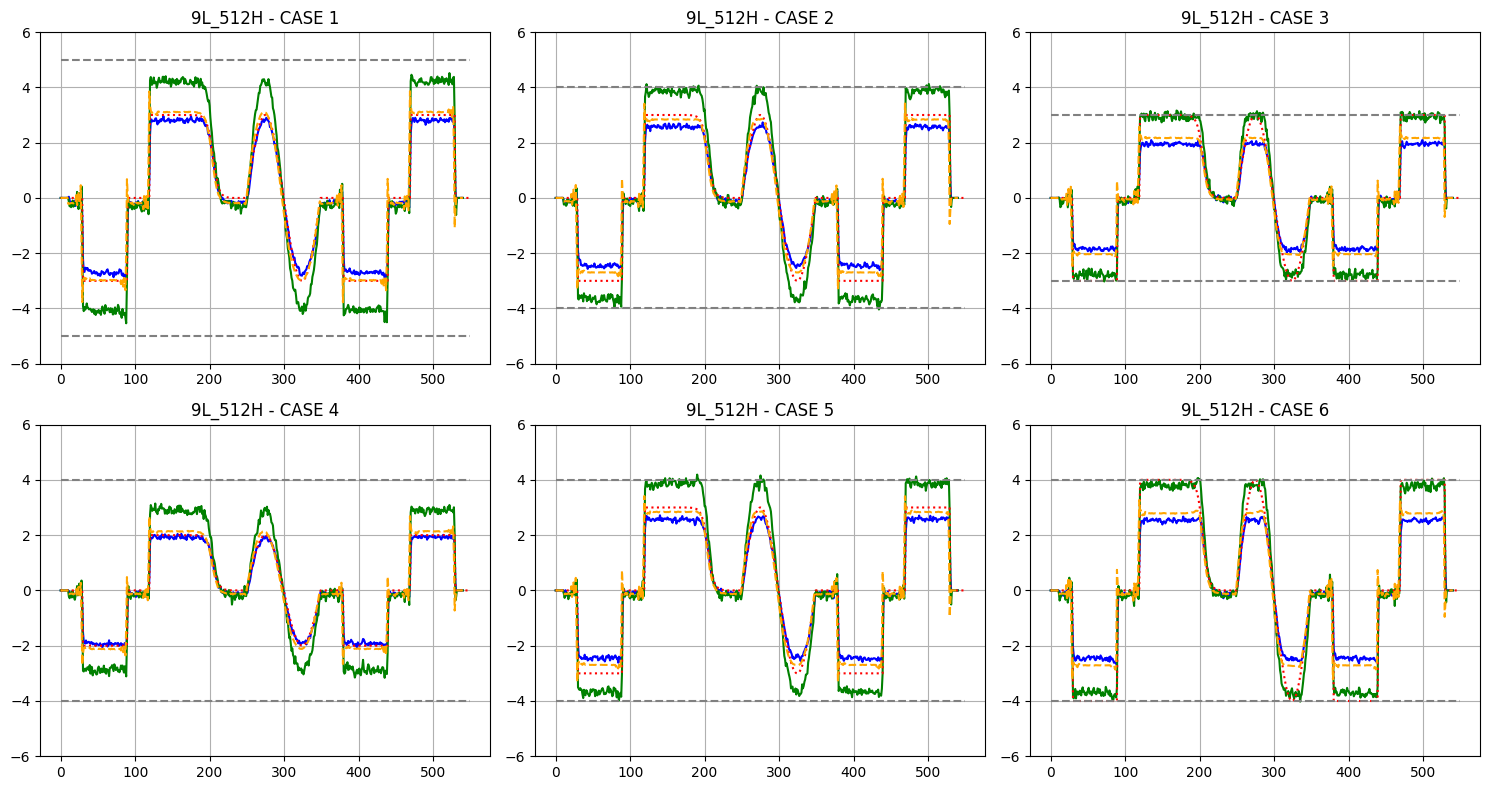


Running model: 9L_256H


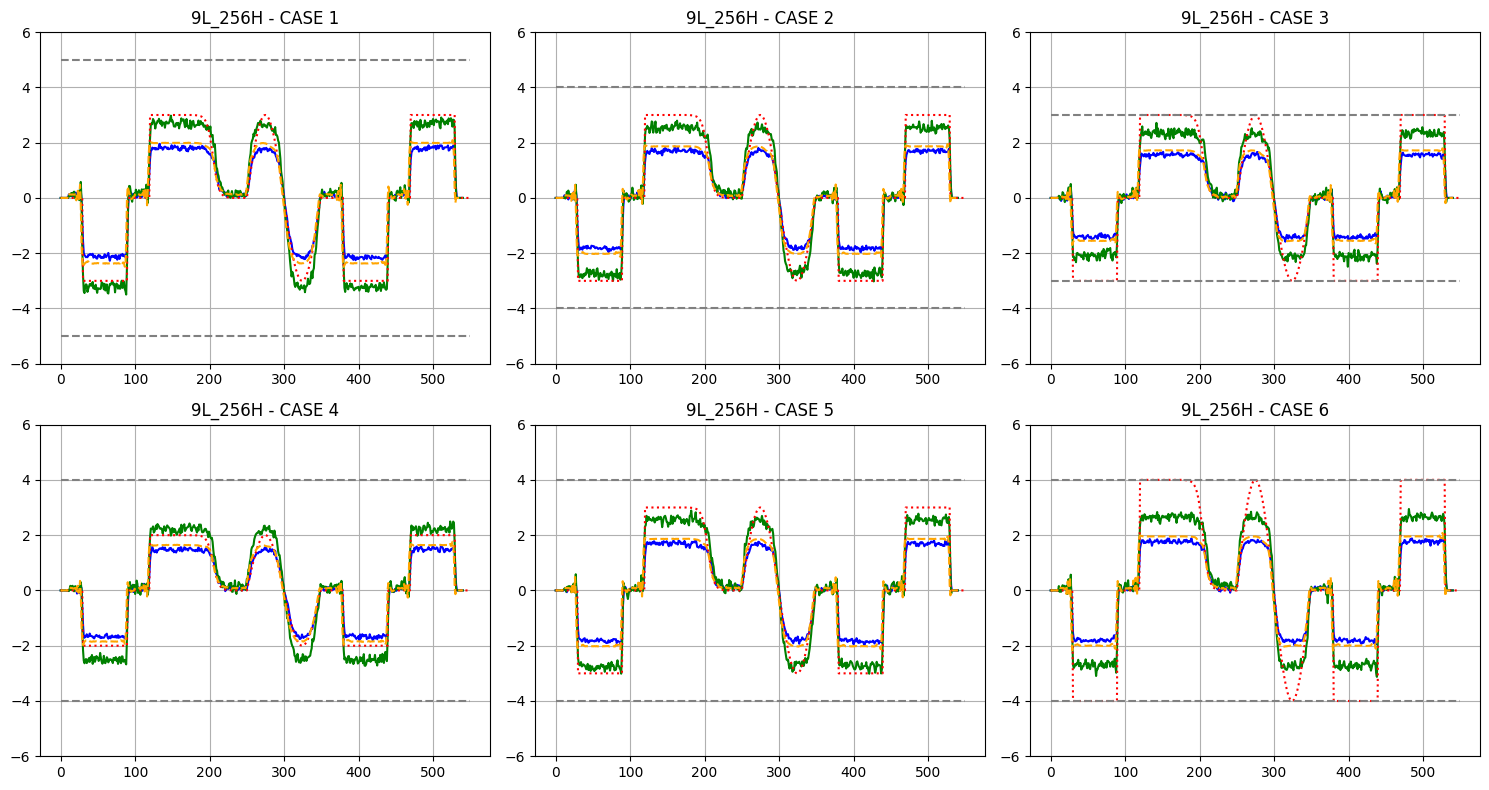


Running model: 9L_128H


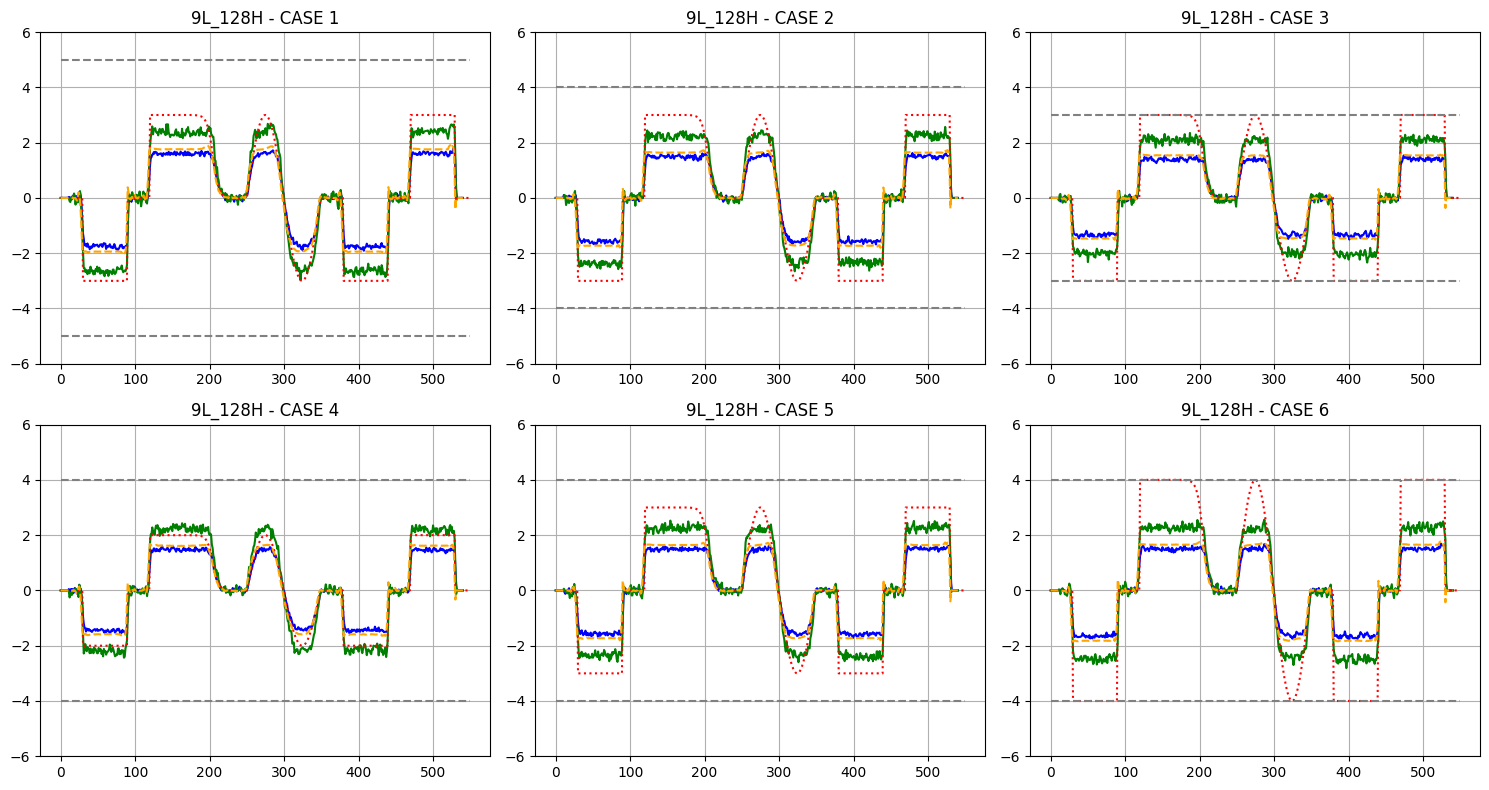

In [ ]:
def run_simulation(model, scale, c_scale):

    with torch.no_grad():

        Ref_traj_step = torch.tensor(np.repeat(np.array([0, -scale, -scale, 0, scale, scale]), 30))

        def sigmoid(x):
            return 1 / (1 + np.exp(-x / 4))

        x = np.linspace(0, 50, 50)
        y = -sigmoid(x - 25) * scale + scale
        Ref_traj_sigmoid = torch.tensor(y)

        x_sin = np.linspace(0, 2 * np.pi, 100)
        y_sin = scale * np.sin(x_sin)
        Ref_traj_sin = torch.tensor(y_sin)

        Ref_traj = torch.cat((
            Ref_traj_step,
            Ref_traj_sigmoid,
            torch.zeros(20),
            Ref_traj_sin,
            Ref_traj_step,
            torch.zeros(20)
        ))
        tot_step = len(Ref_traj)

        C_Ref_traj_low = torch.tensor(np.repeat(np.array([-c_scale]), tot_step))
        C_Ref_traj_up = torch.tensor(np.repeat(np.array([c_scale]), tot_step))

        x1_diff = 9.32425809
        x2_diff = 14.13760952
        u_diff = 9.992800291743697
        window = 10

        Ref_traj = Ref_traj / (x1_diff / 2)
        C_Ref_traj_low = C_Ref_traj_low / (x2_diff / 2)
        C_Ref_traj_up = C_Ref_traj_up / (x2_diff / 2)

        sliding_data_ref_x1 = Ref_traj.unfold(0, window, 1)
        sliding_data_con_x2_low = C_Ref_traj_low.unfold(0, window, 1)
        sliding_data_con_x2_up = C_Ref_traj_up.unfold(0, window, 1)
        sliding_data_con_x2 = torch.stack((sliding_data_con_x2_low, sliding_data_con_x2_up), dim=-1)

        num_steps = len(Ref_traj) - window + 1

        x_trajectory = torch.zeros(num_steps, 2, dtype=torch.float32)
        u_trajectory = torch.zeros(num_steps, 1, dtype=torch.float32)

        for i in range(num_steps - 20):
            x_past = x_trajectory[i:i+window, :].unsqueeze(0)
            u_past = u_trajectory[i:i+window, :].unsqueeze(0)
            x_ref = sliding_data_ref_x1[i+window].unsqueeze(0)
            c_fut = sliding_data_con_x2[i+window].unsqueeze(0)

            u_future, u_now = NNPolicy_iteration(
                x_ref, x_past, u_past, c_fut, model
            )

            u_trajectory[i+window] = u_now.squeeze()

            x_f = x_trajectory[i+window, :].unsqueeze(-1).clone()
            u_f = u_now.unsqueeze(0).unsqueeze(0).clone()

            x_f[0] *= (x1_diff / 2)
            x_f[1] *= (x2_diff / 2)
            u_f[0] *= (u_diff / 2)

            x_next = torch.tensor(
                f_ss(x_f.numpy(), u_f.numpy()),
                dtype=torch.float32
            ).squeeze(-1)

            x_next[0] /= (x1_diff / 2)
            x_next[1] /= (x2_diff / 2)

            x_trajectory[i+window+1, :] = x_next

        x_trajectory[:, 0] *= (x1_diff / 2)
        x_trajectory[:, 1] *= (x2_diff / 2)
        u_trajectory[:, 0] *= (u_diff / 2)
        Ref_traj *= (x1_diff / 2)
        C_Ref_traj_low *= (x2_diff / 2)
        C_Ref_traj_up *= (x2_diff / 2)

    return x_trajectory, u_trajectory, Ref_traj, C_Ref_traj_low, C_Ref_traj_up

# =========================
# 모델 리스트 생성
# =========================
layer_list = [3, 5, 7, 9]
hidden_dim_list = [128, 256, 512]

models = {}
for n_layers, hidden_dim in itertools.product(layer_list, hidden_dim_list):
    name = f"{n_layers}L_{hidden_dim}H"
    print("Loading", name)
    models[name] = load_fcnn_model(name, DPC_PolicyNN)


# =========================
# 테스트 케이스
# =========================
test_cases = [(3,5), (3,4), (3,3), (2,4), (3,4), (4,4)]

# =========================
# 실행 + plotting
# =========================
for model_name, model in models.items():

    print(f"\nRunning model: {model_name}")

    results = [run_simulation(model, scale, c_scale) for scale, c_scale in test_cases]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, (x_traj, u_traj, ref, c_low, c_up) in enumerate(results):
        ax = axes[i]

        ax.plot(x_traj[:, 0].numpy(), label="x1", color="b")
        ax.plot(x_traj[:, 1].numpy(), label="x2", color="g")
        ax.plot(ref.numpy(), label="ref", linestyle="dotted", color="r")
        ax.plot(u_traj[:, 0].numpy(), label="u", linestyle="dashed", color="orange")
        ax.plot(c_low.numpy(), linestyle="dashed", color="gray")
        ax.plot(c_up.numpy(), linestyle="dashed", color="gray")

        ax.set_title(f"{model_name} - CASE {i+1}")
        ax.grid()
        ax.set_ylim(-6, 6)

    plt.tight_layout()
    plt.show()